### ── 타이타닉 matplotlib ──
B1. 나이 히스토그램 (bins=25, 제목·축 레이블 포함)  
B2. 성별 생존자 수 막대그래프  
B3. 나이 vs 요금 산점도 (생존여부 색상 구분)  
B4. 등급별 요금 박스플롯  
B5. 탑승항(Embarked)별 승객 비율 파이차트  
→ 각 차트 PNG로 저장  

### ── IMDB plotly ──
B6. IMDB_Rating 히스토그램 (marginal='box' 포함)  
B7. 투표 수 vs 평점 scatter (hover_name=영화 제목)  
B8. B7 차트를 HTML로 저장

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

import platform
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')    
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')      
else:
    plt.rc('font', family='NanumGothic')      

plt.rc('axes', unicode_minus=False)      

In [9]:
TITANIC_URL = (
  'https://raw.githubusercontent.com/'
  'datasciencedojo/datasets/master/titanic.csv'
)
titanic = pd.read_csv(TITANIC_URL)
imdb = pd.read_csv('./imdb_top_1000.csv')

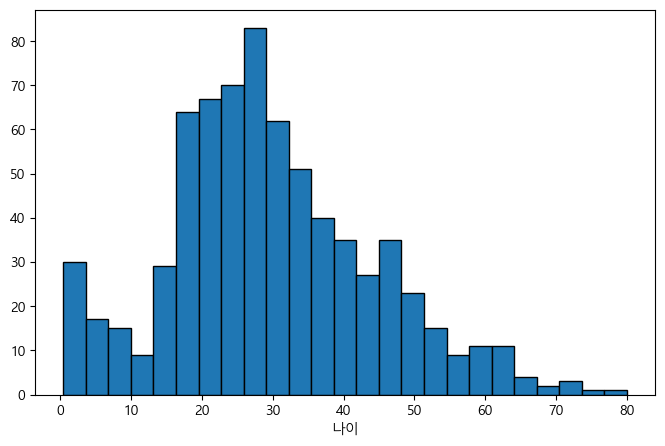

In [10]:
# B1. 나이 히스토그램 (bins=25, 제목·축 레이블 포함)
fig, ax = plt.subplots(figsize=(8,5))
ax.hist(titanic['Age'], bins=25, edgecolor = 'black')
ax.set_xlabel('나이');
plt.show()

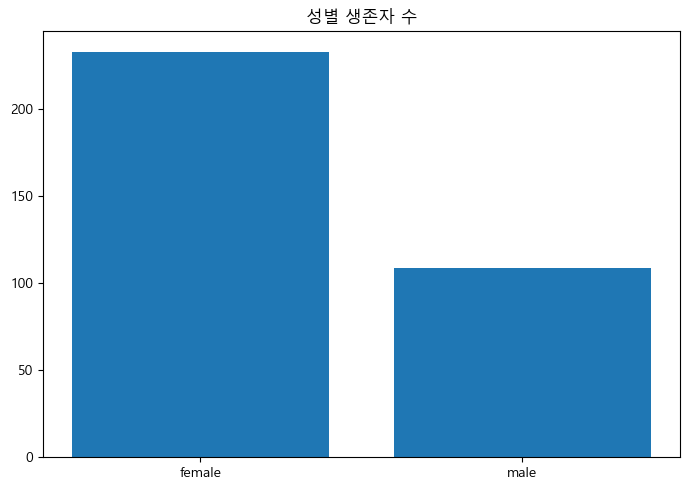

In [11]:
# B2. 성별 생존자 수 막대그래프
surv_class = titanic.groupby('Sex')['Survived'].sum()
fig, ax = plt.subplots(figsize = (7,5))
ax.bar(surv_class.index, surv_class.values)
ax.set_title('성별 생존자 수')
plt.tight_layout(); plt.show()

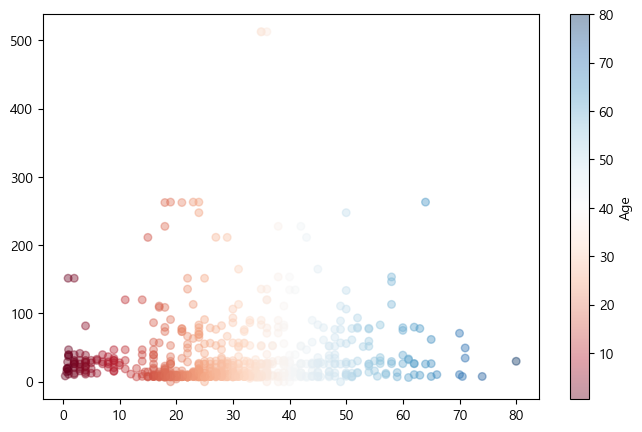

In [12]:
# B3. 나이 vs 요금 산점도 (생존여부 색상 구분)
fig, ax = plt.subplots(figsize=(8,5))
# ax.scatter(titanic['Age'], titanic['Fare'], alpha=0.4, s=30)
scatter = ax.scatter(titanic['Age'], titanic['Fare'], c=titanic['Age'], alpha=0.4, s=30, cmap='RdBu')
cbar = plt.colorbar(scatter)
cbar.set_label('Age')
plt.show()

In [13]:
print(np.sort(titanic['Pclass'].unique()))
sorted(titanic['Pclass'].unique())

[1 2 3]


[np.int64(1), np.int64(2), np.int64(3)]

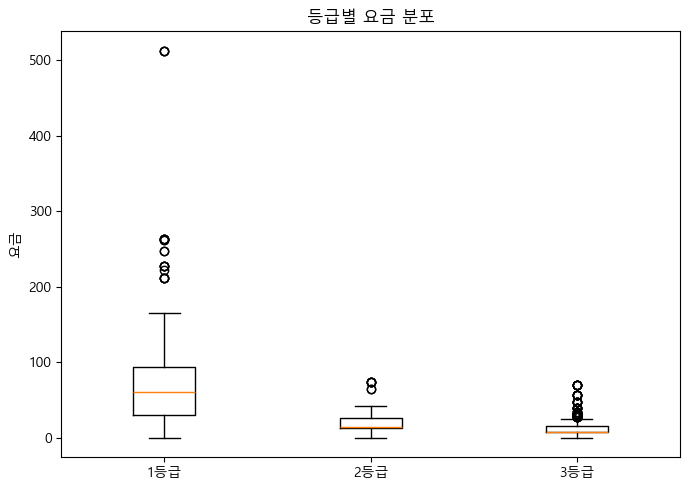

In [14]:
# B4. 등급별 요금 박스플롯 
# data_fare_by_class = [titanic[titanic['Pclass']==c]['Fare'].dropna() for c in np.sort(titanic['Pclass'].unique())]
data_fare_by_class = []
for c in np.sort(titanic['Pclass'].unique()):
    result = titanic[titanic['Pclass'] == c]['Fare'].dropna()
    data_fare_by_class.append(result)

fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot(data_fare_by_class, tick_labels=['1등급','2등급','3등급'])
ax.set_ylabel('요금');
ax.set_title('등급별 요금 분포')
plt.tight_layout(); plt.show()

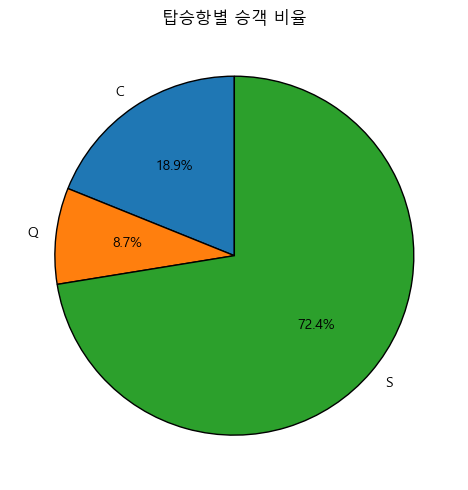

In [15]:
# B5. 탑승항(Embarked)별 승객 비율 파이차트  
embark_counts = titanic['Embarked'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(5,5))
ax.pie(embark_counts, labels = embark_counts.index.tolist(),
       autopct='%1.1f%%', startangle=90,
       wedgeprops=dict(edgecolor='black'))
ax.set_title('탑승항별 승객 비율')
plt.tight_layout();

### APPLIED 서울 아파트 plotly 시계열

sa = pd.read_csv('01_sources/seoul_apartment.csv')  

A1. 월별 평균 거래가격 꺾은선그래프 (HTML 저장)  
A2. 월별 거래 건수 막대그래프 (HTML 저장)  
A3. 구별 평균 거래가격 수평 막대그래프  
    힌트: sa['구'] = sa['시군구'].str.split().str[1]

### A1. 월별 평균 거래가격 꺾은선그래프 (HTML 저장)  


In [16]:
sa = pd.read_csv('seoul_apartment.csv')

In [17]:
# 계약년월이 202001 이런식으로 년과 월이 묶여져있다. 이를 년과 월로 분리하여 column을 만든다.
# isnull 로 확인시 결측값은 없다.
sa['계약년'] = sa['계약년월'] // 100
sa['계약월'] = sa['계약년월'] % 100

sa.head(1)

,NO,시군구,번지,본번,부번,단지명,전용면적(㎡),계약년월,계약일,거래금액(만원),층,건축년도,도로명,계약년,계약월
0,1,서울특별시 종로구 사직동,9,9,0,광화문스페이스본(101동~105동),94.51,200811,3,63000,6,2008,사직로8길 4,2008,11


In [18]:
sa.groupby('계약월').agg(평균거래가격 = ('거래금액(만원)', 'mean')).reset_index()

,계약월,평균거래가격
0,1,56494.625136
1,2,53480.137771
2,3,52231.182929
3,4,55574.591420
4,5,57695.491524
5,6,60286.692320
6,7,60946.101357
7,8,58685.701330
8,9,56100.757776
9,10,55217.457965


In [28]:
fig = px.line(sa.groupby('계약월').agg(평균거래가격 = ('거래금액(만원)', 'mean')).reset_index(),
              x='계약월',
              y='평균거래가격',
              title = '월별 평균 거래 가격',
              markers=True)
fig.update_xaxes(tickmode='linear',tick0=1,dtick=1)
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='LightGray')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='LightGray')
fig.write_html("A1_월별 평균 거래 가격.html")
fig.show()
            

###  A2. 월별 거래 건수 막대그래프 (HTML 저장)  

In [20]:
sa.groupby('계약월').agg(거래건수 = ('NO','count')).reset_index()

,계약월,거래건수
0,1,93015
1,2,97190
2,3,119817
3,4,105436
4,5,105356
5,6,115630
6,7,113717
7,8,107627
8,9,107413
9,10,113976


In [29]:
fig = px.bar(sa.groupby('계약월').agg(거래건수 = ('NO','count')).reset_index(),
              x='계약월',
              y='거래건수',
              title = '월별 평균 거래 건수')
fig.update_xaxes(tickmode='linear',tick0=1,dtick=1)
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='LightGray')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='LightGray')
fig.write_html("A2_월별 평균 거래 건수.html")
fig.show()

### A3. 구별 평균 거래가격 수평 막대그래프  
    힌트: sa['구'] = sa['시군구'].str.split().str[1]

In [22]:
sa['구'] = sa['시군구'].str.split().str[1]
sa.head(1)

,NO,시군구,번지,본번,부번,단지명,전용면적(㎡),계약년월,계약일,거래금액(만원),층,건축년도,도로명,계약년,계약월,구
0,1,서울특별시 종로구 사직동,9,9,0,광화문스페이스본(101동~105동),94.51,200811,3,63000,6,2008,사직로8길 4,2008,11,종로구


In [23]:
sa.groupby('구').agg(평균거래가격 = ('거래금액(만원)','mean')).reset_index()

,구,평균거래가격
0,강남구,114407.316961
1,강동구,54342.551961
2,강북구,36954.817766
3,강서구,42915.184672
4,관악구,40932.049502
5,광진구,65702.391229
6,구로구,37600.366060
7,금천구,32837.716959
8,노원구,32367.035372
9,도봉구,30932.942208


In [30]:
fig = px.bar(sa.groupby('구').agg(평균거래가격 = ('거래금액(만원)','mean')).reset_index(),
            x='평균거래가격',
            y='구',
            title = '구별 평균 거래 가격',
            orientation='h',
            )
# fig.update_xaxes(tickmode='linear',tick0=1,dtick=1)
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='LightGray')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='LightGray')
fig.write_html("A3_구별 평균 거래 가격.html")
fig.show()

### IMDB 장르 심화 분석

##### Genre = 'Crime, Drama' 형태 → 쪼개서 분석
imdb_genre = imdb.copy()  
imdb_genre['Genre'] = imdb_genre['Genre'].str.split(',')  
imdb_genre = imdb_genre.explode('Genre')  
imdb_genre['Genre'] = imdb_genre['Genre'].str.strip()  

C1. 장르별 평균 IMDB 평점 수평 막대 (10편 이상만)  
C2. 연도별 평균 평점 추이 scatter  
C3. Gross 전처리 후 흥행 vs 평점 scatter  
    imdb['Gross_clean'] = imdb['Gross'].str.replace(',','', regex=False).astype(float)